Running t-SNE on extracted CNN features...


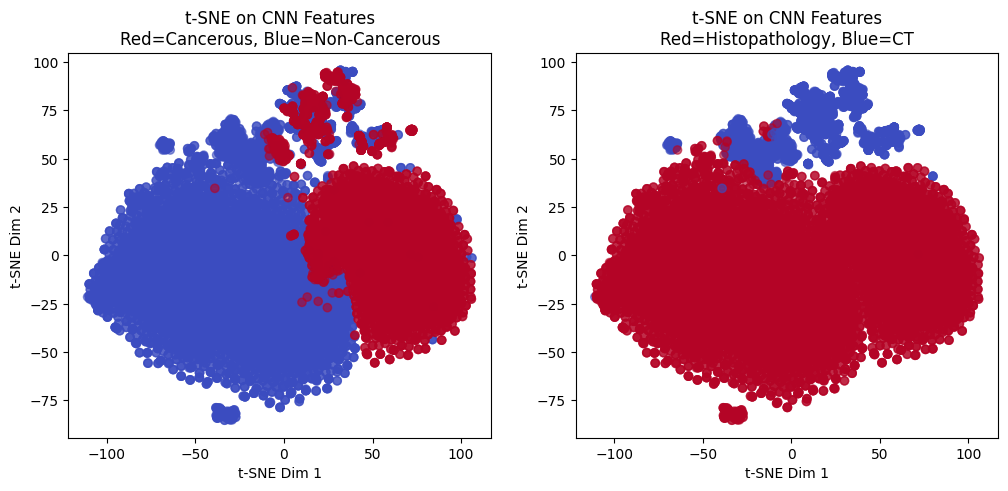

In [8]:
import os
import random

# Avoid OpenBLAS + OpenMP conflict
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# -------------------------------
# Set seeds for reproducibility
# -------------------------------
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -------------------------------
# CNN Model Definition
# -------------------------------
class CustomCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(2, 3, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4, 4),

            nn.Conv2d(3, 3, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(4, 4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 7 * 7, 7),
            nn.ReLU(),
            nn.Linear(7, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# -------------------------------
# Dataset Loader with Modality Info
# -------------------------------
class CustomDatasetWithModality(datasets.ImageFolder):
    def __getitem__(self, index):
        path, label = self.samples[index]
        img = self.loader(path)
        img = self.transform(img)
        modality = 0 if 'CT' in path else 1  # CT=0, Histopathology=1
        return img, label, modality

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

dataset = CustomDatasetWithModality(root='/kaggle/input/tsne-dataset-v3/tsne-dataset-v3', transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# -------------------------------
# Load the Trained Model
# -------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomCNN(num_classes=2).to(device)
model.load_state_dict(torch.load('/kaggle/input/cnn1-kd-lung-tsne-v2/pytorch/default/1/best_distilled_student_model_cnn1.pth', map_location=device))
model.eval()

# -------------------------------
# Feature Extraction
# -------------------------------
features_cnn = []
labels_list = []
modalities_list = []

def extract_features(x):
    return model.features(x).view(x.size(0), -1)

with torch.no_grad():
    for inputs, labels, modalities in dataloader:
        inputs = inputs.to(device)
        feats_cnn = extract_features(inputs).cpu().numpy()

        features_cnn.append(feats_cnn)
        labels_list.append(labels.cpu().numpy())
        modalities_list.append(modalities.numpy())

features_cnn = np.concatenate(features_cnn)
labels_all = np.concatenate(labels_list)        # 0=non-cancerous, 1=cancerous
modalities_all = np.concatenate(modalities_list)  # 0=CT, 1=histopathology

# -------------------------------
# t-SNE Visualization after CNN features (with fixed seed)
# -------------------------------
print("Running t-SNE on extracted CNN features...")
tsne_cnn = TSNE(n_components=2, random_state=seed, perplexity=30).fit_transform(features_cnn)

# -------------------------------
# Plotting both
# -------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(tsne_cnn[:, 0], tsne_cnn[:, 1], c=labels_all, cmap='coolwarm', alpha=0.6)
plt.title("t-SNE on CNN Features\nRed=Cancerous, Blue=Non-Cancerous")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")

plt.subplot(1, 2, 2)
plt.scatter(tsne_cnn[:, 0], tsne_cnn[:, 1], c=modalities_all, cmap='coolwarm', alpha=0.6)
plt.title("t-SNE on CNN Features\nRed=Histopathology, Blue=CT")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")

plt.show()
